# MakeMore — Part 3: Activations, Gradients & Batch Normalization

**Based on:** Andrej Karpathy's "Building makeMore Part 3: Activations & Gradients, BatchNorm"  

## Overview

We deepen and improve the MLP from Part 2 by investigating **what goes wrong at init** and how to fix it.  
The core topics are:

1. **Weight initialization** — why poorly-scaled weights cause saturated activations & vanishing gradients.
2. **Kaiming initialization** — principled scaling of weights to preserve activation variance through layers.
3. **Batch Normalization** — normalize pre-activations inside the network so initialization doesn't matter as much.
4. **A clean PyTorch-style layer API** — `Linear`, `BatchNorm1d`, `Tanh` classes that mirror `nn.Module`.
5. **Activation & gradient diagnostics** — histograms to detect dead neurons and vanishing/exploding gradients.
6. **Update-to-data ratio monitoring** — a key diagnostic from Karpathy: `log10(lr * grad.std() / data.std())` ≈ -3.

**MLflow** tracks every training run and logs diagnostic plots as artifacts.

---

## 1. Setup

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
import mlflow

%matplotlib inline

SEED = 2147483647

print(f"PyTorch version : {torch.__version__}")
print(f"MLflow  version : {mlflow.__version__}")

PyTorch version : 2.11.0+cu128
MLflow  version : 3.11.1


In [2]:
# ── Device Setup ──────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"  GPU : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
  GPU : NVIDIA GeForce RTX 5080 Laptop GPU
  VRAM: 16.6 GB


In [3]:
EXPERIMENT_NAME = "makemore-part3-batchnorm"
mlflow.set_experiment(EXPERIMENT_NAME)
print(f"MLflow experiment: '{EXPERIMENT_NAME}'")

2026/04/24 13:16:09 INFO mlflow.tracking.fluent: Experiment with name 'makemore-part3-batchnorm' does not exist. Creating a new experiment.


MLflow experiment: 'makemore-part3-batchnorm'


## 2. Data Loading & Dataset Construction

In [4]:
with open('data/names.txt', 'r') as f:
    words = f.read().splitlines()

# Vocabulary
chars = sorted(set(''.join(words)))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
VOCAB_SIZE = len(itos)   # 27

print(f"Words: {len(words):,}  |  Vocab size: {VOCAB_SIZE}")

Words: 32,033  |  Vocab size: 27


In [5]:
BLOCK_SIZE = 3

def build_dataset(words: list[str], block_size: int) -> tuple[torch.Tensor, torch.Tensor]:
    """Build (X, Y) context→target tensors and move them to the target device."""
    X, Y = [], []
    for word in words:
        context = [0] * block_size
        for ch in word + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X).to(device), torch.tensor(Y).to(device)


random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr,  Ytr  = build_dataset(words[:n1],   BLOCK_SIZE)
Xdev, Ydev = build_dataset(words[n1:n2], BLOCK_SIZE)
Xte,  Yte  = build_dataset(words[n2:],   BLOCK_SIZE)

print(f"Train : {Xtr.shape}  |  Dev : {Xdev.shape}  |  Test : {Xte.shape}")
print(f"Device: {Xtr.device}")

Train : torch.Size([182625, 3])  |  Dev : torch.Size([22655, 3])  |  Test : torch.Size([22866, 3])
Device: cuda:0


---
## 3. PyTorch-Style Layer Classes

We build minimal layer classes that mirror `torch.nn.Module`'s interface.  
Each class implements `__call__` (forward pass) and `parameters()` (list of learnable tensors).

### 3.1 Linear Layer

In [6]:
class Linear:
    """Fully-connected linear layer: out = x @ W + b.

    Weight is initialized with Kaiming / He initialization:
        W ~ N(0, 1) / sqrt(fan_in)
    which keeps activation variance roughly constant across layers.
    """

    def __init__(self, fan_in: int, fan_out: int, bias: bool = True, device=None):
        g = torch.Generator().manual_seed(SEED)
        self.weight = (torch.randn((fan_in, fan_out), generator=g) / fan_in ** 0.5).to(device)
        self.bias   = torch.zeros(fan_out, device=device) if bias else None

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self) -> list[torch.Tensor]:
        return [self.weight] + ([] if self.bias is None else [self.bias])

### 3.2 Batch Normalization Layer

**Batch Normalization** (Ioffe & Szegedy, 2015) normalizes the pre-activations within each mini-batch:

$$\hat{x} = \frac{x - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}} \qquad y = \gamma \hat{x} + \beta$$

- During **training**: $\mu_B$ and $\sigma_B^2$ are computed from the current batch; running stats are updated via EMA.
- During **inference**: frozen running stats are used — no dependence on batch size.

In [7]:
class BatchNorm1d:
    """1-D Batch Normalization.

    Normalizes each feature across the batch, then applies a learned
    scale (gamma) and shift (beta). Running statistics are maintained
    for use during inference.
    """

    def __init__(self, dim: int, eps: float = 1e-5, momentum: float = 0.1, device=None):
        self.eps      = eps
        self.momentum = momentum
        self.training = True
        # Learnable parameters (trained by backprop)
        self.gamma = torch.ones(dim,  device=device)   # scale
        self.beta  = torch.zeros(dim, device=device)   # shift
        # Running buffers (updated via exponential moving average)
        self.running_mean = torch.zeros(dim, device=device)
        self.running_var  = torch.ones(dim,  device=device)

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        if self.training:
            xmean = x.mean(0, keepdim=True)   # (1, dim) batch mean
            xvar  = x.var(0,  keepdim=True)   # (1, dim) batch variance
        else:
            xmean = self.running_mean
            xvar  = self.running_var

        # Normalize to zero mean and unit variance
        xhat    = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        # Update running statistics (EMA, no gradient)
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean.squeeze(0)
                self.running_var  = (1 - self.momentum) * self.running_var  + self.momentum * xvar.squeeze(0)
        return self.out

    def parameters(self) -> list[torch.Tensor]:
        return [self.gamma, self.beta]

### 3.3 Tanh Activation

In [8]:
class Tanh:
    """Tanh activation. Stores output for gradient diagnostics."""

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        self.out = torch.tanh(x)
        return self.out

    def parameters(self) -> list[torch.Tensor]:
        return []

---
## 4. Build the Deep MLP

Architecture: **5 hidden layers**, each `Linear → BatchNorm1d → Tanh`, followed by a final `Linear → BatchNorm1d` output layer.

Key initialization tricks applied:
- All `Linear` layers use **Kaiming init** (`/ fan_in**0.5`).
- The **last BatchNorm's gamma** is scaled by `0.1` so initial logits are near-uniform (avoids confidently-wrong predictions at step 0).

In [11]:
def build_model(
    vocab_size: int,
    block_size: int,
    n_embd: int   = 10,
    n_hidden: int = 100,
    device: torch.device = torch.device("cpu"),
) -> tuple[torch.Tensor, list, list[torch.Tensor]]:
    """Build embedding table C, layer stack, and parameter list.

    Returns (C, layers, parameters).
    """
    g = torch.Generator().manual_seed(SEED)
    # Create on CPU first, then move — avoids CPU-generator + CUDA-device mismatch
    C = torch.randn((vocab_size, n_embd), generator=g).to(device)

    layers = [
        Linear(n_embd * block_size, n_hidden, bias=False, device=device), BatchNorm1d(n_hidden, device=device), Tanh(),
        Linear(n_hidden,            n_hidden, bias=False, device=device), BatchNorm1d(n_hidden, device=device), Tanh(),
        Linear(n_hidden,            n_hidden, bias=False, device=device), BatchNorm1d(n_hidden, device=device), Tanh(),
        Linear(n_hidden,            n_hidden, bias=False, device=device), BatchNorm1d(n_hidden, device=device), Tanh(),
        Linear(n_hidden,            n_hidden, bias=False, device=device), BatchNorm1d(n_hidden, device=device), Tanh(),
        Linear(n_hidden,        vocab_size,   bias=False, device=device), BatchNorm1d(vocab_size, device=device),
    ]

    with torch.no_grad():
        # Scale the final BN gamma down so initial logits are near-uniform.
        # This avoids a large initial loss from confidently-wrong predictions.
        layers[-1].gamma *= 0.1

    parameters = [C] + [p for layer in layers for p in layer.parameters()]
    for p in parameters:
        p.requires_grad = True

    total = sum(p.nelement() for p in parameters)
    print(f"Total parameters : {total:,}  (device: {device})")
    return C, layers, parameters


In [12]:
N_EMBD   = 10
N_HIDDEN = 100

C, layers, parameters = build_model(
    vocab_size=VOCAB_SIZE,
    block_size=BLOCK_SIZE,
    n_embd=N_EMBD,
    n_hidden=N_HIDDEN,
    device=device,
)

Total parameters : 47,024  (device: cuda)


---
## 5. Training with MLflow Tracking

We track the **update-to-data ratio** `ud[i]` = `log10(lr * grad.std() / data.std())` for each parameter.  
The rule of thumb: this ratio should be approximately **1e-3** (i.e., ~ -3 on a log10 scale).

In [13]:
def train(
    C: torch.Tensor,
    layers: list,
    parameters: list[torch.Tensor],
    Xtr: torch.Tensor,
    Ytr: torch.Tensor,
    num_steps: int     = 200_000,
    batch_size: int    = 32,
    lr_high: float     = 0.1,
    lr_low: float      = 0.01,
    lr_decay_step: int = 150_000,
    log_every: int     = 10_000,
    seed: int          = SEED,
) -> dict:
    """Train the deep MLP and return training history including update/data ratios."""
    g = torch.Generator().manual_seed(seed)
    lossi, ud, steps_logged = [], [], []

    for step in range(1, num_steps + 1):
        # ── Minibatch ─────────────────────────────────────────────────────────
        ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
        Xb, Yb = Xtr[ix], Ytr[ix]

        # ── Forward pass ──────────────────────────────────────────────────────
        emb = C[Xb]                              # (B, block_size, n_embd)
        x   = emb.view(emb.shape[0], -1)         # (B, block_size * n_embd)
        for layer in layers:
            x = layer(x)
        loss = F.cross_entropy(x, Yb)

        # ── Backward pass ─────────────────────────────────────────────────────
        # Retain grads on layer outputs for diagnostics
        for layer in layers:
            if hasattr(layer, 'out'):
                layer.out.retain_grad()
        for p in parameters:
            p.grad = None
        loss.backward()

        # ── LR schedule + parameter update ───────────────────────────────────
        lr = lr_high if step < lr_decay_step else lr_low
        with torch.no_grad():
            for p in parameters:
                p.data -= lr * p.grad

        # ── Diagnostics ───────────────────────────────────────────────────────
        lossi.append(loss.log10().item())
        with torch.no_grad():
            ud.append([
                ((lr * p.grad).std() / p.data.std()).log10().item()
                for p in parameters
            ])

        if step % log_every == 0 or step == 1:
            steps_logged.append(step)
            print(f"  step {step:>7,}/{num_steps:,} | loss {loss.item():.4f}")

    return {"lossi": lossi, "ud": ud, "steps_logged": steps_logged}

Training...
  step       1/200,000 | loss 3.2789
  step  10,000/200,000 | loss 2.0841
  step  20,000/200,000 | loss 1.9124
  step  30,000/200,000 | loss 2.2759
  step  40,000/200,000 | loss 1.9916
  step  50,000/200,000 | loss 2.0717
  step  60,000/200,000 | loss 2.2325
  step  70,000/200,000 | loss 2.2151
  step  80,000/200,000 | loss 2.0050
  step  90,000/200,000 | loss 2.4694
  step 100,000/200,000 | loss 1.9972
  step 110,000/200,000 | loss 2.2540
  step 120,000/200,000 | loss 1.4987
  step 130,000/200,000 | loss 1.9762
  step 140,000/200,000 | loss 1.9417
  step 150,000/200,000 | loss 2.6287
  step 160,000/200,000 | loss 1.7085
  step 170,000/200,000 | loss 2.0113
  step 180,000/200,000 | loss 2.0140
  step 190,000/200,000 | loss 1.8262
  step 200,000/200,000 | loss 2.1015


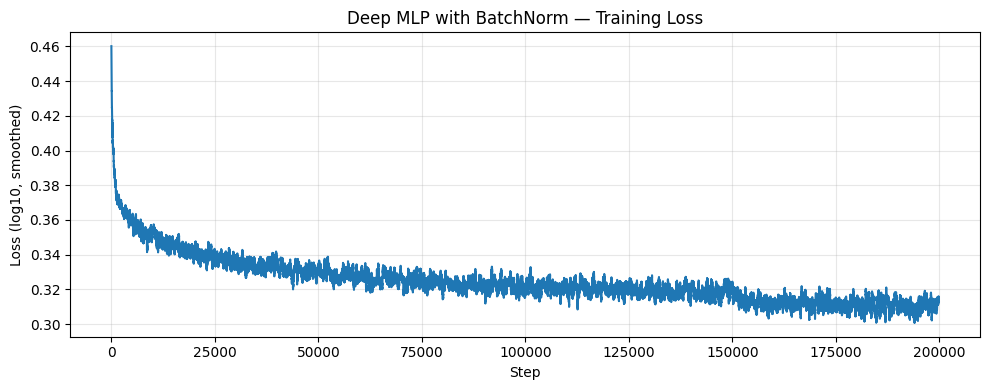


Done training.


In [14]:
NUM_STEPS  = 200_000
BATCH_SIZE = 32
LR_HIGH    = 0.1
LR_LOW     = 0.01
LR_DECAY   = 150_000

with mlflow.start_run(run_name="deep-mlp-batchnorm"):

    mlflow.log_params({
        "model"         : "deep-mlp-batchnorm",
        "block_size"    : BLOCK_SIZE,
        "n_embd"        : N_EMBD,
        "n_hidden"      : N_HIDDEN,
        "num_layers"    : 5,
        "num_steps"     : NUM_STEPS,
        "batch_size"    : BATCH_SIZE,
        "lr_high"       : LR_HIGH,
        "lr_low"        : LR_LOW,
        "lr_decay_step" : LR_DECAY,
        "device"        : str(device),
        "total_params"  : sum(p.nelement() for p in parameters),
    })

    print("Training...")
    history = train(
        C, layers, parameters, Xtr, Ytr,
        num_steps=NUM_STEPS,
        batch_size=BATCH_SIZE,
        lr_high=LR_HIGH,
        lr_low=LR_LOW,
        lr_decay_step=LR_DECAY,
    )

    # Log smoothed loss every 1000 steps
    lossi = history["lossi"]
    for step in range(0, len(lossi), 1000):
        avg = sum(lossi[step:step+1000]) / min(1000, len(lossi) - step)
        mlflow.log_metric("train_loss_log10", avg, step=step)

    # ── Plot 1: smoothed loss curve ───────────────────────────────────────────
    smooth_k = 200
    smoothed  = [sum(lossi[i:i+smooth_k])/smooth_k for i in range(0, len(lossi)-smooth_k)]
    fig, ax   = plt.subplots(figsize=(10, 4))
    ax.plot(smoothed)
    ax.set_xlabel("Step")
    ax.set_ylabel("Loss (log10, smoothed)")
    ax.set_title("Deep MLP with BatchNorm — Training Loss")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("p3_loss_curve.png", dpi=100)
    mlflow.log_artifact("p3_loss_curve.png")
    plt.show()

    print("\nDone training.")

---
## 6. Diagnostic Visualizations

### 6.1 Activation Distribution (tanh outputs)

If activations are **saturated** (most values near ±1), gradients vanish and learning stops. We want distributions that look roughly Gaussian and centred near zero.

Layer  2 (Tanh): mean=+0.016  std=0.712  saturated=18.2%
Layer  5 (Tanh): mean=+0.007  std=0.746  saturated=21.3%
Layer  8 (Tanh): mean=+0.011  std=0.782  saturated=21.5%
Layer 11 (Tanh): mean=-0.007  std=0.802  saturated=23.1%
Layer 14 (Tanh): mean=+0.019  std=0.800  saturated=25.9%


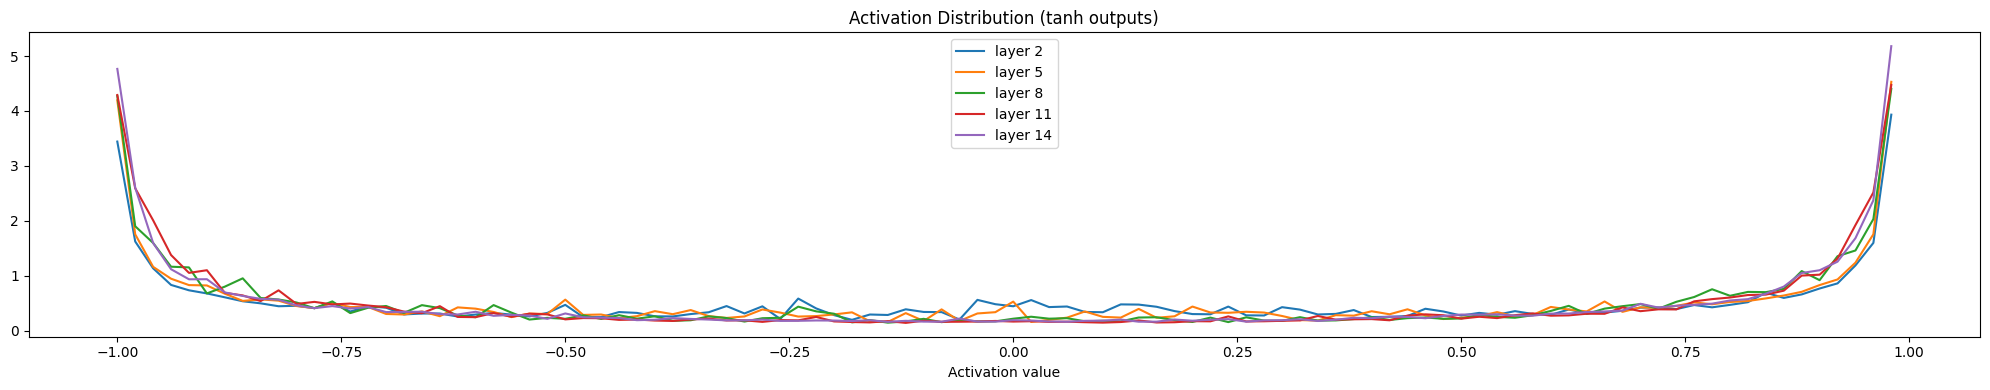

In [15]:
# Run ONE forward pass through the full training set (no grad) to populate layer.out
with torch.no_grad():
    emb_diag = C[Xtr[:2048]]
    x_diag   = emb_diag.view(emb_diag.shape[0], -1)
    for layer in layers:
        x_diag = layer(x_diag)

fig, ax = plt.subplots(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers):
    if isinstance(layer, Tanh):
        t = layer.out.cpu()
        sat = (t.abs() > 0.97).float().mean() * 100
        print(f"Layer {i:2d} (Tanh): mean={t.mean():+.3f}  std={t.std():.3f}  saturated={sat:.1f}%")
        hy, hx = torch.histogram(t, density=True)
        ax.plot(hx[:-1].detach(), hy.detach())
        legends.append(f"layer {i}")
ax.legend(legends)
ax.set_title("Activation Distribution (tanh outputs)")
ax.set_xlabel("Activation value")
plt.tight_layout()
plt.savefig("p3_activation_dist.png", dpi=100)
plt.show()

### 6.2 Gradient Distribution (tanh output gradients)

Healthy gradients should be roughly equal in scale across all layers.  
Vanishing gradients show up as very small std in earlier layers.

Layer  2 (Tanh grad): mean=-4.66e-12  std=4.77e-03
Layer  5 (Tanh grad): mean=-4.66e-12  std=3.93e-03
Layer  8 (Tanh grad): mean=+1.16e-12  std=3.59e-03
Layer 11 (Tanh grad): mean=+9.90e-12  std=3.61e-03
Layer 14 (Tanh grad): mean=+3.49e-12  std=3.77e-03


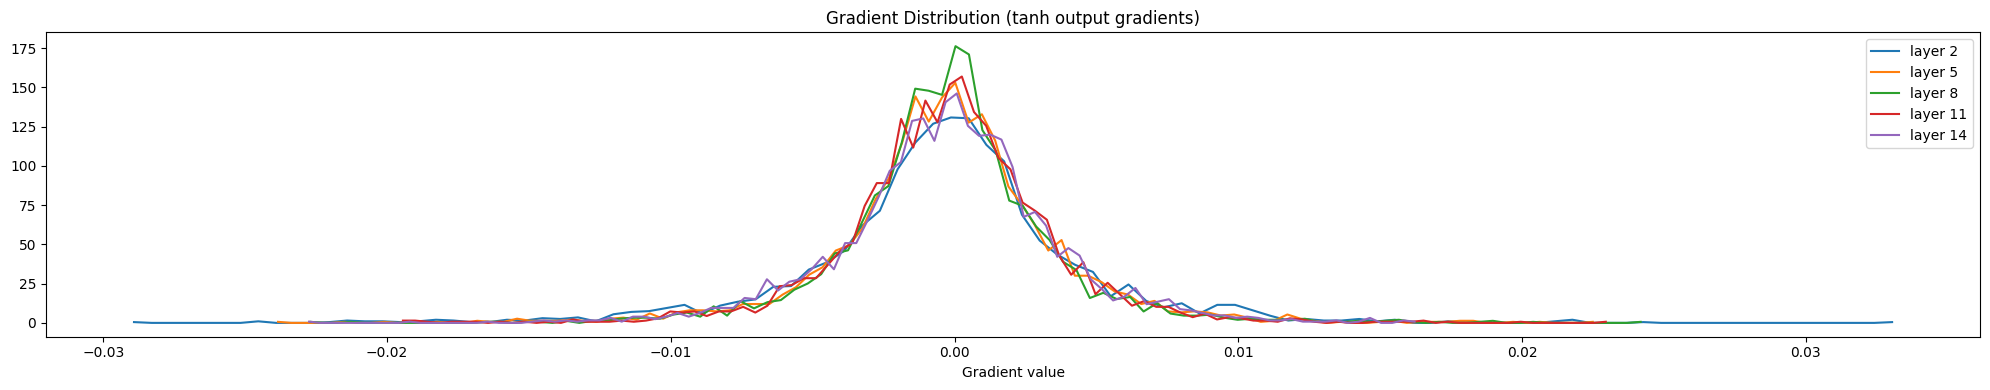

In [16]:
# Run a forward + backward pass on a single batch to get gradients
ix    = torch.randint(0, Xtr.shape[0], (BATCH_SIZE,))
emb   = C[Xtr[ix]]
x_g   = emb.view(emb.shape[0], -1)
for layer in layers:
    x_g = layer(x_g)
    if hasattr(layer, 'out'):
        layer.out.retain_grad()
loss_g = F.cross_entropy(x_g, Ytr[ix])
for p in parameters: p.grad = None
loss_g.backward()

fig, ax = plt.subplots(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers):
    if isinstance(layer, Tanh) and layer.out.grad is not None:
        t = layer.out.grad.cpu()
        print(f"Layer {i:2d} (Tanh grad): mean={t.mean():+.2e}  std={t.std():.2e}")
        hy, hx = torch.histogram(t, density=True)
        ax.plot(hx[:-1].detach(), hy.detach())
        legends.append(f"layer {i}")
ax.legend(legends)
ax.set_title("Gradient Distribution (tanh output gradients)")
ax.set_xlabel("Gradient value")
plt.tight_layout()
plt.savefig("p3_gradient_dist.png", dpi=100)
plt.show()

### 6.3 Weight Gradient Distribution

Weight (27, 10) | mean=-6.90e-12 | std=1.88e-02 | ratio=1.66e-02
Weight (30, 100) | mean=+3.08e-04 | std=9.08e-03 | ratio=2.27e-02
Weight (100, 100) | mean=-5.37e-05 | std=5.91e-03 | ratio=2.44e-02
Weight (100, 100) | mean=+6.87e-07 | std=5.71e-03 | ratio=2.40e-02
Weight (100, 100) | mean=+3.11e-05 | std=5.36e-03 | ratio=2.34e-02
Weight (100, 100) | mean=-5.61e-05 | std=5.04e-03 | ratio=2.33e-02
Weight (100, 27) | mean=-1.40e-04 | std=8.19e-03 | ratio=2.35e-02


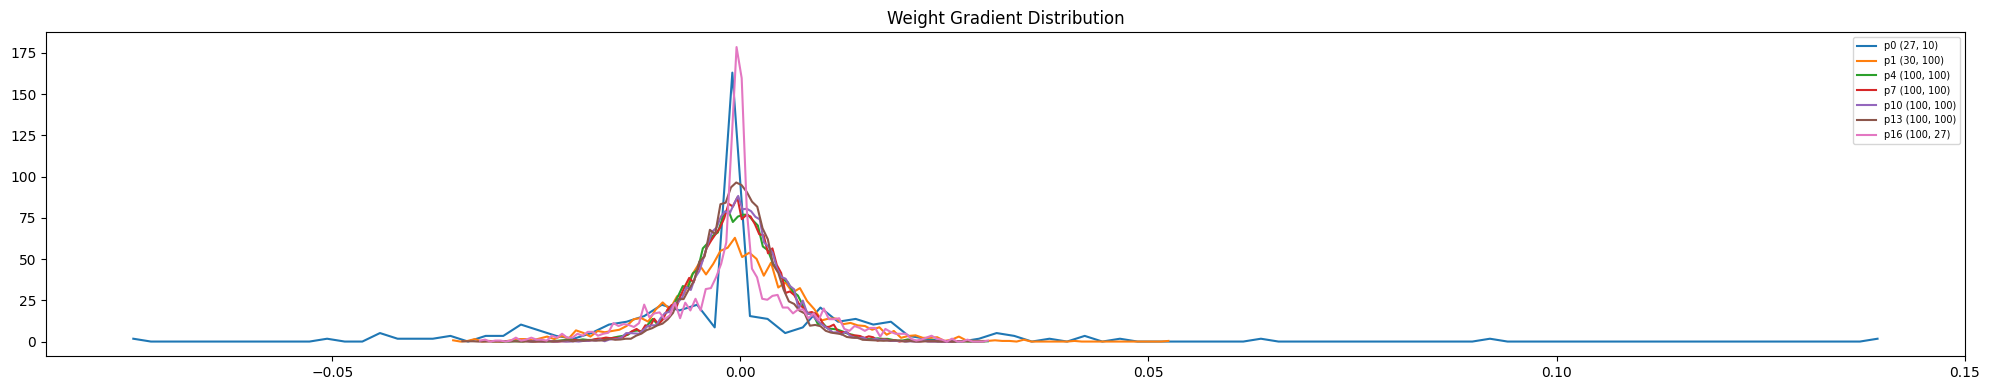

In [17]:
fig, ax = plt.subplots(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
    if p.grad is not None and p.ndim == 2:
        t = p.grad.cpu()
        print(f"Weight {tuple(p.shape)} | mean={t.mean():+.2e} | std={t.std():.2e} | ratio={t.std()/p.cpu().std():.2e}")
        hy, hx = torch.histogram(t, density=True)
        ax.plot(hx[:-1].detach(), hy.detach())
        legends.append(f"p{i} {tuple(p.shape)}")
ax.legend(legends, fontsize=7)
ax.set_title("Weight Gradient Distribution")
plt.tight_layout()
plt.savefig("p3_weight_grad_dist.png", dpi=100)
plt.show()

### 6.4 Update-to-Data Ratio

The **update-to-data ratio** `log10(lr * ||grad|| / ||param||)` should hover around **−3** for healthy training.  
Too high → parameters change too fast. Too low → learning is stalled.

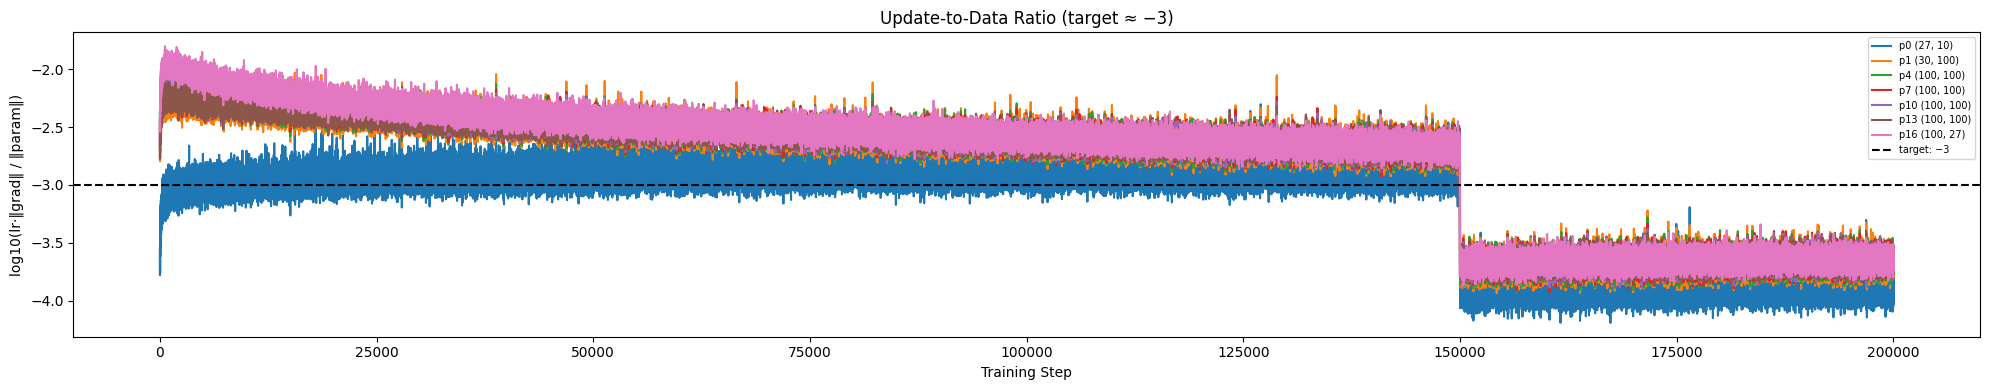

In [18]:
ud = history["ud"]

fig, ax = plt.subplots(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:   # only plot weight matrices (skip scalars)
        ax.plot([ud[j][i] for j in range(len(ud))])
        legends.append(f"p{i} {tuple(p.shape)}")

ax.axhline(-3, color='black', linestyle='--', linewidth=1.5, label='target: −3')
ax.set_xlabel("Training Step")
ax.set_ylabel("log10(lr·‖grad‖ / ‖param‖)")
ax.set_title("Update-to-Data Ratio (target ≈ −3)")
ax.legend(legends + ['target: −3'], fontsize=7)
plt.tight_layout()
plt.savefig("p3_update_ratio.png", dpi=100)
mlflow.log_artifact("p3_update_ratio.png")
plt.show()

---
## 7. Evaluation on All Splits

In [19]:
@torch.no_grad()
def evaluate_split(
    split: str,
    C: torch.Tensor,
    layers: list,
) -> float:
    """Evaluate cross-entropy loss for train / val / test split.
    Switches all BatchNorm layers to eval mode (uses running stats).
    """
    X, Y = {"train": (Xtr, Ytr), "val": (Xdev, Ydev), "test": (Xte, Yte)}[split]

    # Switch to eval mode — BatchNorm uses running statistics
    for layer in layers:
        if hasattr(layer, 'training'):
            layer.training = False

    emb  = C[X]
    x    = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Y).item()

    # Switch back to train mode
    for layer in layers:
        if hasattr(layer, 'training'):
            layer.training = True

    return loss


train_loss = evaluate_split("train", C, layers)
val_loss   = evaluate_split("val",   C, layers)
test_loss  = evaluate_split("test",  C, layers)

print(f"Train loss : {train_loss:.4f}")
print(f"Val   loss : {val_loss:.4f}")
print(f"Test  loss : {test_loss:.4f}")

with mlflow.start_run(run_name="deep-mlp-batchnorm-eval", nested=True):
    mlflow.log_metrics({
        "train_loss": train_loss,
        "val_loss"  : val_loss,
        "test_loss" : test_loss,
    })

Train loss : 2.0014
Val   loss : 2.0807
Test  loss : 2.0800


---
## 8. Sampling Generated Names

In [20]:
@torch.no_grad()
def sample_names(
    C: torch.Tensor,
    layers: list,
    block_size: int,
    itos: dict,
    num_samples: int = 20,
    seed: int        = SEED + 10,
) -> list[str]:
    """Autoregressively sample names from the trained model.
    Uses CPU copies so seeded torch.multinomial works correctly.
    """
    # Switch to eval mode and move to CPU for sampling
    C_cpu      = C.detach().cpu()
    cpu_layers = []
    for layer in layers:
        if hasattr(layer, 'training'):
            layer.training = False
        if isinstance(layer, Linear):
            l2  = Linear.__new__(Linear)
            l2.weight = layer.weight.detach().cpu()
            l2.bias   = layer.bias.detach().cpu() if layer.bias is not None else None
            cpu_layers.append(l2)
        elif isinstance(layer, BatchNorm1d):
            bn2 = BatchNorm1d.__new__(BatchNorm1d)
            bn2.eps          = layer.eps
            bn2.momentum     = layer.momentum
            bn2.training     = False   # use running stats
            bn2.gamma        = layer.gamma.detach().cpu()
            bn2.beta         = layer.beta.detach().cpu()
            bn2.running_mean = layer.running_mean.detach().cpu()
            bn2.running_var  = layer.running_var.detach().cpu()
            cpu_layers.append(bn2)
        else:
            cpu_layers.append(layer)   # Tanh — stateless

    g = torch.Generator().manual_seed(seed)
    samples = []

    for _ in range(num_samples):
        out     = []
        context = [0] * block_size
        while True:
            emb   = C_cpu[torch.tensor([context])]        # (1, block_size, n_embd)
            x     = emb.view(1, -1)
            for layer in cpu_layers:
                x = layer(x)
            probs = F.softmax(x, dim=1)
            ix    = torch.multinomial(probs, num_samples=1, generator=g).item()
            context = context[1:] + [ix]
            if ix == 0:
                break
            out.append(itos[ix])
        samples.append(''.join(out))

    return samples


generated = sample_names(C, layers, BLOCK_SIZE, itos, num_samples=20)
print("Generated names (Deep MLP + BatchNorm):")
for name in generated:
    print(f"  {name}")

Generated names (Deep MLP + BatchNorm):
  carmahzabelle
  khi
  mili
  taty
  skanden
  jazzuel
  deliah
  jareei
  nellara
  chaiir
  kaleigh
  ham
  port
  quint
  shoilea
  jadilyn
  jero
  dearyn
  kai
  evells


---
## 9. Hyperparameter Sweep: Effect of n_hidden on BatchNorm Models

In [22]:
mlflow.end_run()   # close any stale run left open from a previous cell

sweep_configs = [
    {"n_embd": 10, "n_hidden":  64, "num_steps": 100_000},
    {"n_embd": 10, "n_hidden": 100, "num_steps": 100_000},
    {"n_embd": 10, "n_hidden": 200, "num_steps": 100_000},
]

sweep_results = []

for cfg in sweep_configs:
    run_name = f"n_hidden={cfg['n_hidden']}"
    with mlflow.start_run(run_name=run_name):

        C_sw, layers_sw, params_sw = build_model(
            vocab_size=VOCAB_SIZE,
            block_size=BLOCK_SIZE,
            n_embd=cfg["n_embd"],
            n_hidden=cfg["n_hidden"],
            device=device,
        )

        mlflow.log_params({
            "model"        : "deep-mlp-batchnorm",
            "n_embd"       : cfg["n_embd"],
            "n_hidden"     : cfg["n_hidden"],
            "num_steps"    : cfg["num_steps"],
            "device"       : str(device),
            "total_params" : sum(p.nelement() for p in params_sw),
        })

        hist_sw = train(
            C_sw, layers_sw, params_sw, Xtr, Ytr,
            num_steps=cfg["num_steps"],
            lr_decay_step=cfg["num_steps"] // 2,
        )

        val_loss_sw = evaluate_split("val", C_sw, layers_sw)
        mlflow.log_metric("val_loss", val_loss_sw)
        sweep_results.append({**cfg, "val_loss": val_loss_sw})

    print(f"{run_name:<20} val_loss = {val_loss_sw:.4f}")

print("\nBest configuration:")
print(min(sweep_results, key=lambda r: r["val_loss"]))


Total parameters : 20,996  (device: cuda)
  step       1/100,000 | loss 3.2829
  step  10,000/100,000 | loss 2.0657
  step  20,000/100,000 | loss 1.8145
  step  30,000/100,000 | loss 2.2757
  step  40,000/100,000 | loss 2.1267
  step  50,000/100,000 | loss 2.1301
  step  60,000/100,000 | loss 2.3177
  step  70,000/100,000 | loss 2.2664
  step  80,000/100,000 | loss 1.9895
  step  90,000/100,000 | loss 2.4671
  step 100,000/100,000 | loss 2.1453
n_hidden=64          val_loss = 2.1231
Total parameters : 47,024  (device: cuda)
  step       1/100,000 | loss 3.2789
  step  10,000/100,000 | loss 2.0841
  step  20,000/100,000 | loss 1.9124
  step  30,000/100,000 | loss 2.2759
  step  40,000/100,000 | loss 1.9916
  step  50,000/100,000 | loss 2.0717
  step  60,000/100,000 | loss 2.1090
  step  70,000/100,000 | loss 2.1450
  step  80,000/100,000 | loss 1.9640
  step  90,000/100,000 | loss 2.4251
  step 100,000/100,000 | loss 2.0586
n_hidden=100         val_loss = 2.0970
Total parameters : 173,7

---
## 10. Summary

| Concept | Key Takeaway |
|---|---|
| **Saturated tanh** | Weights too large → activations near ±1 → near-zero gradients → no learning |
| **Kaiming init** | Scale `W` by `1/√fan_in` to preserve variance of activations across layers |
| **Batch Normalization** | Normalizes pre-activations per batch; makes training robust to bad init |
| **BN at inference** | Uses EMA running statistics — no dependence on batch size |
| **Final layer gamma×0.1** | Avoids confidently-wrong predictions at step 0 (flat initial loss) |
| **Update-to-data ratio** | `log10(lr·‖Δ‖/‖w‖) ≈ −3` is the healthy target; too high/low → tune LR |
| **Layer API (`Linear`, `BatchNorm1d`, `Tanh`)** | Mirrors `nn.Module`; easy to stack and inspect |
| **GPU** | All tensors on `device`; CPU copies used for seeded sampling |
| **MLflow** | Logs params, loss curve, and diagnostic plots as artifacts |

**Next:** Part 4 — Becoming a Backprop Ninja (manual backward pass).